# Indian & Thai Currency Recognition – Generalization Study

This notebook evaluates the generalization ability of the proposed
YOLO-assisted ROI classification pipeline on **Indian and Thai banknotes**.
SO this experiment is not intended to compare RAW and ROI representations.
Instead, it evaluates whether the proposed YOLO-assisted ROI classification
pipeline, originally developed for Yemeni banknotes, can generalize to unseen
currencies with different visual styles, denominations, and backgrounds.

All model components, training settings, and data augmentation strategies are
kept identical to ensure a fair assessment of cross-dataset generalization.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Yemeni-Currency-Recognition


Mounted at /content/drive
/content/drive/MyDrive/Yemeni-Currency-Recognition


In [ ]:
# ===== Environment =====
!pip install -r requirements.txt
!pip uninstall -y jax jaxlib

In [1]:
%cd /content/drive/MyDrive/Yemeni-Currency-Recognition

import tensorflow as tf
import numpy as np
import os, json, random, cv2
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("TF:", tf.__version__)
print("NumPy:", np.__version__)

# Reproducibility
os.environ["SEED"] = "1337"

# Training config
os.environ["IMG_SIZE"] = "224"
os.environ["BATCH"]    = "32"
os.environ["EPOCHS"]   = "10"
os.environ["N_FOLDS"]  = "5"

IMG_SIZE = (224,224)
BATCH = 32

/content/drive/MyDrive/Yemeni-Currency-Recognition
TF: 2.16.1
NumPy: 1.26.4


In [2]:
# Download unified Indian + Thai dataset
!python src/data/download_indian_thai.py

Download completed.
Extracting outer ZIP...
Extracting inner ZIP...
Organizing dataset into unified classes...

INDIAN + THAI DATASET READY
IndianBankNotes_INDIA100NEW             : 200
IndianBankNotes_INDIA100OLD             : 200
IndianBankNotes_INDIA10NEW              : 200
IndianBankNotes_INDIA10OLD              : 200
IndianBankNotes_INDIA20                 : 200
IndianBankNotes_INDIA200                : 200
IndianBankNotes_INDIA2000               : 200
IndianBankNotes_INDIA500                : 200
IndianBankNotes_INDIA50NEW              : 200
IndianBankNotes_INDIA50OLD              : 200
ThaiBankNotes_THAI100                   : 160
ThaiBankNotes_THAI1000                  : 160
ThaiBankNotes_THAI20                    : 160
ThaiBankNotes_THAI50                    : 160
ThaiBankNotes_THAI500                   : 160

TOTAL images: 2800

Final dataset location:
/content/IndianThai_data/RAW


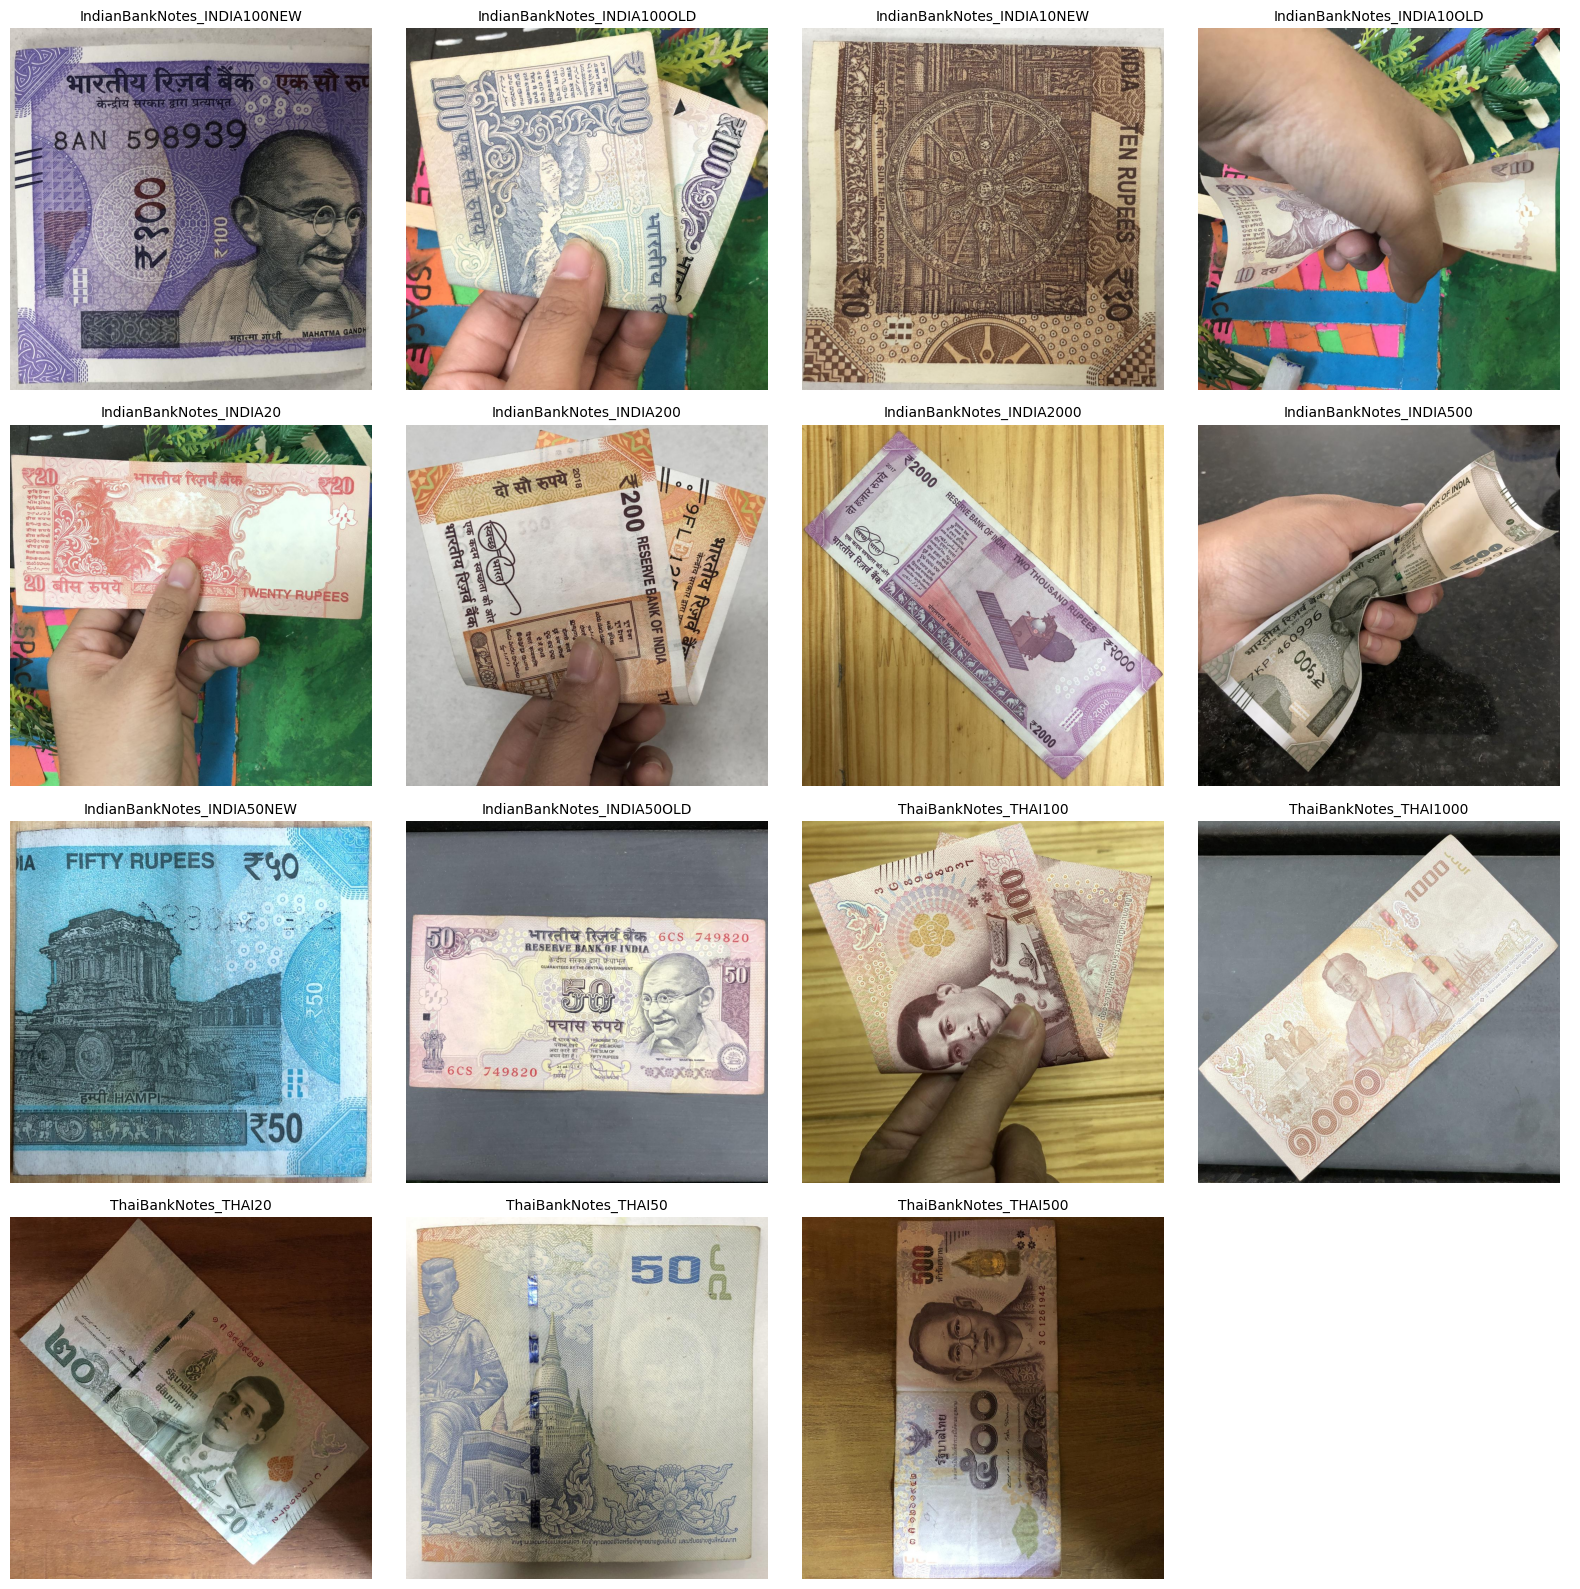

In [4]:
# ===== Grid visualization: ONE image per class =====


DATA_ROOT = Path("/content/IndianThai_data/RAW")

classes = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])

n_cols = 4
n_rows = math.ceil(len(classes) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()

for i, cls in enumerate(classes):
    imgs = list((DATA_ROOT / cls).glob("*"))
    img_path = random.choice(imgs)

    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis("off")


for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
#Stratified Split (15% Test + 5-Fold CV)
os.environ["RAW_ROOT"]   = "/content/IndianThai_data/RAW"
os.environ["TEST_ROOT"]  = "/content/IndianThai_data_test"
os.environ["FOLDS_ROOT"] = "/content/IndianThai_folds/raw"
os.environ["N_FOLDS"]    = "5"

!python src/data/split_cv.py


Total images: 2800
Classes: ['IndianBankNotes_INDIA100NEW', 'IndianBankNotes_INDIA100OLD', 'IndianBankNotes_INDIA10NEW', 'IndianBankNotes_INDIA10OLD', 'IndianBankNotes_INDIA20', 'IndianBankNotes_INDIA200', 'IndianBankNotes_INDIA2000', 'IndianBankNotes_INDIA500', 'IndianBankNotes_INDIA50NEW', 'IndianBankNotes_INDIA50OLD', 'ThaiBankNotes_THAI100', 'ThaiBankNotes_THAI1000', 'ThaiBankNotes_THAI20', 'ThaiBankNotes_THAI50', 'ThaiBankNotes_THAI500']
Held-out test set created at: /content/IndianThai_data_test
Fold 1 created
Fold 2 created
Fold 3 created
Fold 4 created
Fold 5 created
5-Fold CV split completed successfully


#Build ROI using Yemeni-trained YOLO (Zero-Shot)

In [ ]:

os.environ["RAW_FOLDS_ROOT"] = "/content/IndianThai_folds/raw"
os.environ["ROI_FOLDS_ROOT"] = "/content/IndianThai_folds/roi"
os.environ["YOLO_WEIGHTS"]   = "/content/drive/MyDrive/YOLO/banknote_detector/best.pt"

!python src/data/build_roi.py


Building ROI for fold_1
Building ROI for fold_2
Building ROI for fold_3
Building ROI for fold_4
Building ROI for fold_5
ROI generation completed successfully


In [ ]:
RAW_SAMPLE = Path("/content/IndianThai_folds/raw/fold_2/train")
ROI_SAMPLE = Path("/content/IndianThai_folds/roi/fold_2/train")

cls = random.choice([d for d in RAW_SAMPLE.iterdir() if d.is_dir()])
img = random.choice(list(cls.glob("*")))

raw_img = cv2.cvtColor(cv2.imread(str(img)), cv2.COLOR_BGR2RGB)
roi_img = cv2.cvtColor(cv2.imread(str(ROI_SAMPLE/cls.name/img.name)), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); plt.imshow(raw_img); plt.title("RAW"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(roi_img); plt.title("ROI (YOLO)"); plt.axis("off")
plt.show()

#Train Model

In [ ]:
os.environ["FOLDS_ROOT"]   = "/content/IndianThai_folds/roi"
os.environ["EXP_NAME"]     = "ROI"
os.environ["RESULTS_ROOT"] = "/content/IndianThai_results"

!python src/train/train.py

In [ ]:
import shutil

SRC = Path("/content/IndianThai_results")
DST = Path("/content/drive/MyDrive/IndianThai_Currency-Results")

DST.mkdir(parents=True, exist_ok=True)
shutil.copytree(SRC, DST, dirs_exist_ok=True)

print("Indian & Thai results saved to Drive")

Indian & Thai results saved to Drive


In [ ]:

SRC = Path("/content/drive/MyDrive/IndianThai_Currency-Results")
DST = Path("/content/IndianThai_results")

if DST.exists():
    shutil.rmtree(DST)
shutil.copytree(SRC, DST)

print("Indian & Thai results restored from Drive")


In [ ]:
from pathlib import Path
import tensorflow as tf
from tensorflow import keras

IMG_SIZE = (224, 224)
BATCH = 32


MODEL_PATH = Path("/content/drive/MyDrive/IndianThai_CV_Results/model_raw_fold4.keras")
model = "/content/IndianThai_results/model_fold2.keras"

print("Model loaded successfully")


bg_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data_bg_only/test",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)

loss, acc = model.evaluate(bg_ds, verbose=0)

print("="*50)
print("BACKGROUND-ONLY TEST RESULT")
print("="*50)
print(f"Accuracy: {acc*100:.2f}%")
print(f"Loss    : {loss:.4f}")


Model loaded successfully
Found 420 files belonging to 15 classes.
BACKGROUND-ONLY TEST RESULT
Accuracy: 71.67%
Loss    : 1.0060


In [ ]:
from pathlib import Path
import tensorflow as tf
from tensorflow import keras

IMG_SIZE = (224, 224)
BATCH = 32


model = keras.models.load_model(
    "/content/IndianThai_results/model_fold2.keras"
)

print("Model loaded successfully")


bg_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data_bg_only/test",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)


loss, acc = model.evaluate(bg_ds, verbose=0)

print("="*50)
print("BACKGROUND-ONLY TEST RESULT")
print("="*50)
print(f"Accuracy: {acc*100:.2f}%")
print(f"Loss    : {loss:.4f}")


Model loaded successfully
Found 420 files belonging to 15 classes.
BACKGROUND-ONLY TEST RESULT
Accuracy: 69.52%
Loss    : 1.2585


In [ ]:
import json, numpy as np, pandas as pd

res_roi = json.load(open("/content/IndianThai_results/cv_results.json"))

df = pd.DataFrame({
    "Fold": range(1, len(res_roi["val_acc"])+1),
    "ROI Val Acc": res_roi["val_acc"]
})

display(df)

print(f"ROI Mean Accuracy: {np.mean(res_roi['val_acc'])*100:.2f}%")
print(f"ROI Std : {np.std(res_roi['val_acc'])*100:.2f}%")


,Fold,ROI Val Acc
0,1,0.993697
1,2,0.991597
2,3,0.995798
3,4,0.989496
4,5,0.995798


ROI Mean Accuracy: 99.33%
ROI Std : 0.24%


Best ROI Model + Test Evaluation

In [ ]:
import json
res_roi = json.load(open("/content/IndianThai_results/cv_results.json"))

best_idx = int(np.argmax(res_roi["val_acc"]))

roi_model = tf.keras.models.load_model(
    f"/content/IndianThai_results/model_fold{best_idx}.keras"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/IndianThai_data_test",
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

loss, acc = roi_model.evaluate(test_ds, verbose=0)

print(f"Final Test Accuracy (ROI): {acc*100:.2f}%")
print(f"Final Test Loss (ROI): {loss:.4f}")


Found 420 files belonging to 15 classes.
Final Test Accuracy (ROI): 99.76%
Final Test Loss (ROI): 0.0061


#Confusion Matrix

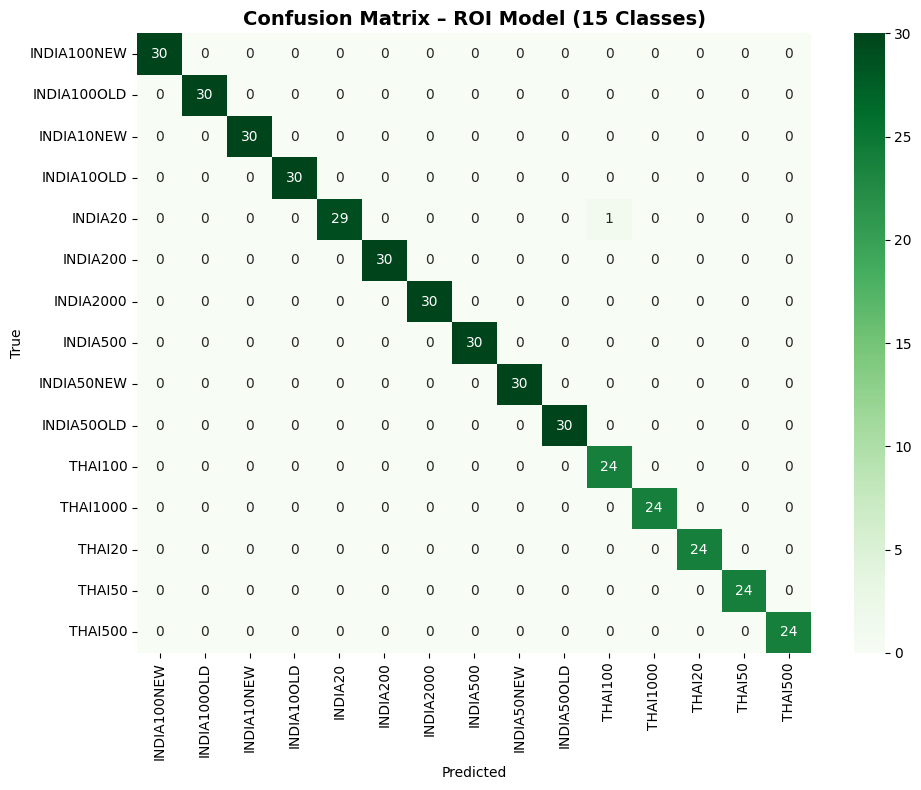

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


def collect_preds(model, ds):
    y_t, y_p = [], []
    for x, y in ds:
        p = model.predict(x, verbose=0).argmax(axis=1)
        y_t.extend(y.numpy())
        y_p.extend(p)
    return np.array(y_t), np.array(y_p)

# Predictions
y_true, y_pred = collect_preds(roi_model, test_ds)
cm = confusion_matrix(y_true, y_pred)

def simplify_name(name):

    return name.split("_")[-1]

short_names = [simplify_name(c) for c in test_ds.class_names]

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=short_names,
    yticklabels=short_names
)
plt.title("Confusion Matrix – ROI Model (15 Classes)", fontsize=14, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Collect predictions
y_true, y_pred = [], []
for x, y in test_ds:
    p = roi_model.predict(x, verbose=0).argmax(axis=1)
    y_true.extend(y.numpy())
    y_pred.extend(p)

print("="*60)
print("CLASSIFICATION REPORT – ROI MODEL (Indian & Thai)")
print("="*60)

report_roi = classification_report(
    y_true,
    y_pred,
    target_names=test_ds.class_names,
    digits=4
)
print(report_roi)


                             precision    recall  f1-score   support

IndianBankNotes_INDIA100NEW     1.0000    1.0000    1.0000        30
IndianBankNotes_INDIA100OLD     1.0000    1.0000    1.0000        30
 IndianBankNotes_INDIA10NEW     1.0000    1.0000    1.0000        30
 IndianBankNotes_INDIA10OLD     1.0000    1.0000    1.0000        30
    IndianBankNotes_INDIA20     1.0000    0.9667    0.9831        30
   IndianBankNotes_INDIA200     1.0000    1.0000    1.0000        30
  IndianBankNotes_INDIA2000     1.0000    1.0000    1.0000        30
   IndianBankNotes_INDIA500     1.0000    1.0000    1.0000        30
 IndianBankNotes_INDIA50NEW     1.0000    1.0000    1.0000        30
 IndianBankNotes_INDIA50OLD     1.0000    1.0000    1.0000        30
      ThaiBankNotes_THAI100     0.9600    1.0000    0.9796        24
     ThaiBankNotes_THAI1000     1.0000    1.0000    1.0000        24
       ThaiBankNotes_THAI20     1.0000    1.0000    1.0000        24
       ThaiBankNotes_THAI50     1

Number of ROI misclassifications: 1
Image path: /content/IndianThai_data_test/IndianBankNotes_INDIA20/INDIA20_43.jpg


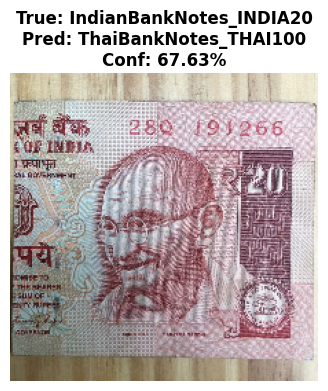

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mis_samples = []

idx = 0
file_paths = test_ds.file_paths

for x_batch, y_batch in test_ds:
    preds = roi_model.predict(x_batch, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    for i in range(len(y_batch)):
        if pred_labels[i] != y_batch[i]:
            mis_samples.append({
                "image": x_batch[i].numpy(),
                "true": int(y_batch[i]),
                "pred": int(pred_labels[i]),
                "conf": float(np.max(preds[i])),
                "path": file_paths[idx]
            })
        idx += 1

print(f"Number of ROI misclassifications: {len(mis_samples)}")


if len(mis_samples) > 0:
    s = mis_samples[0]
    print("Image path:", s["path"])
    plt.figure(figsize=(4,4))
    plt.imshow(s["image"].astype("uint8"))
    plt.axis("off")
    plt.title(
        f"True: {test_ds.class_names[s['true']]}\n"
        f"Pred: {test_ds.class_names[s['pred']]}\n"
        f"Conf: {s['conf']*100:.2f}%",
        fontweight="bold"
    )
    plt.show()


The YOLO-assisted ROI classification pipeline demonstrates strong generalization to Indian and Thai banknotes without any modification to the original Yemeni training setup. The consistently high accuracy confirms the robustness and transferability of the proposed approach
across different currencies and visual conditions.